# Kutsal Kitaplar Metin Analizi
## Zipf Yasasi ve Metin On Isleme (NLP Preprocessing)

Bu notebook, uc kutsal kitap veri seti (Kuran, Incil ve Tevrat) uzerinde temel dogal dil isleme (NLP) on isleme adimlarini ve Zipf Yasasi analizini gerceklestirmektedir.

**Veri Setleri:**
- **Kuran** (Quran): 6.236 ayet
- **Incil** (Bible): 25.250 ayet
- **Tevrat** (Torah): 5.852 ayet

**Islenecek Sutun:** `ayet` (Ingilizce ceviri metinleri)

## 1. Kutuphanelerin Yuklenmesi

Bu projede asagidaki kutuphaneler kullanilmaktadir:

| Kutuphane | Kullanim Amaci |
|-----------|---------------|
| `pandas` | Veri yukleme, DataFrame islemleri ve CSV disa aktarma |
| `numpy` | Sayisal hesaplamalar |
| `matplotlib` | Zipf Yasasi gorsellestirmesi (log-log grafik) |
| `nltk` | Tokenization, Stop Word cikarma, Lemmatization, Stemming |
| `re` | Duzenli ifadeler ile metin temizligi |
| `collections` | Kelime frekans sayimi |

In [2]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import os

# NLTK - Natural Language Toolkit
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer, SnowballStemmer

# Matplotlib stil ayari
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Tum kutuphaneler basariyla yuklendi.")

Tum kutuphaneler basariyla yuklendi.


## 2. Veri Yukleme ve Raporlama

### Veri Seti Kaynaklari

| Veri Seti | Kaynak | Dosya Boyutu |
|-----------|--------|-------------|
| **Kuran (Quran)** | [Kaggle - The Quran Dataset](https://www.kaggle.com/datasets/imrankhan197/the-quran-dataset?select=The+Quran+Dataset.csv) | 4 MB |
| **Incil & Tevrat (Bible)** | [GitHub - Bible Data (AlamoPolyglot)](https://github.com/BradyStephenson/bible-data/blob/main/AlamoPolyglot.csv) | 29.4 MB |

### Veri Seti Bilgileri

| Ozellik | Aciklama |
|---------|----------|
| **Kuran** | 6.236 ayet, 114 sure, 30 cuz |
| **Incil** | 25.250 ayet (book_id >= 6) |
| **Tevrat** | 5.852 ayet (incil book_id < 6, ilk 5 kitap: Genesis, Exodus, Leviticus, Numbers, Deuteronomy) |
| **Toplam** | 37.338 ayet |
| **Format** | CSV (Comma-Separated Values) |
| **Dil** | Ingilizce (ceviri metinleri) |
| **Islenecek Sutun** | `ayet` - Kutsal kitap ayetlerinin Ingilizce cevirileri |

### Ortak Sutun Yapisi

| Sutun | Aciklama |
|-------|----------|
| `sure_no` | Sure/Kitap numarasi |
| `sure_ismi` | Sure/Kitap adi |
| `bolum` | Bolum numarasi (Kuran: Cuz, Incil/Tevrat: Chapter) |
| `ayet_no` | Ayet numarasi |
| `ayet` | Ayet metni (Ingilizce) |
| `kaynak` | Veri seti kaynagi (Kuran / Incil / Tevrat) |

Asagidaki kod, uc veri setini yukler, Tevrat'i Bible veri setinden ayirir ve birlesik bir DataFrame olusturur.

In [3]:
DATA_DIR = "data"

# --- Ham verileri yukle ---
quran_raw = pd.read_csv(os.path.join(DATA_DIR, "quran.csv"))
bible_raw = pd.read_csv(os.path.join(DATA_DIR, "bible.csv"))

# --- Tevrat: Bible'dan book_id < 6 (ilk 5 kitap) ---
torah_raw = bible_raw[bible_raw["book_id"] < 6].copy()
incil_raw = bible_raw[bible_raw["book_id"] >= 6].copy()

# --- Tevrat'i ayri CSV olarak kaydet ---
torah_raw.to_csv(os.path.join(DATA_DIR, "tevrat.csv"), index=False, encoding="utf-8-sig")
print("tevrat.csv olusturuldu.")

# --- Ortak sutun yapisina donustur ---
kuran = quran_raw[["surah_no", "surah_name_roman", "juz_no", "ayah_no_surah", "ayah_en"]].copy()
kuran.columns = ["sure_no", "sure_ismi", "bolum", "ayet_no", "ayet"]
kuran["kaynak"] = "Kuran"

incil = incil_raw[["book_id", "book_name", "chapter", "verse", "world_english_bible_web"]].copy()
incil.columns = ["sure_no", "sure_ismi", "bolum", "ayet_no", "ayet"]
incil["kaynak"] = "Incil"

tevrat = torah_raw[["book_id", "book_name", "chapter", "verse", "world_english_bible_web"]].copy()
tevrat.columns = ["sure_no", "sure_ismi", "bolum", "ayet_no", "ayet"]
tevrat["kaynak"] = "Tevrat"

# --- Birlestir ---
df = pd.concat([kuran, incil, tevrat], ignore_index=True)
df["ayet"] = df["ayet"].fillna("")

print(f"\n{'='*60}")
print(f"Toplam satir sayisi: {len(df):,}")
print(f"  - Kuran : {len(kuran):,}")
print(f"  - Incil : {len(incil):,}")
print(f"  - Tevrat: {len(tevrat):,}")
print(f"\nSutunlar: {df.columns.tolist()}")
print(f"\nVeri seti onizleme:")
df.head(10)

tevrat.csv olusturuldu.

Toplam satir sayisi: 37,338
  - Kuran : 6,236
  - Incil : 25,250
  - Tevrat: 5,852

Sutunlar: ['sure_no', 'sure_ismi', 'bolum', 'ayet_no', 'ayet', 'kaynak']

Veri seti onizleme:


,sure_no,sure_ismi,bolum,ayet_no,ayet,kaynak
0,1,Al-Fatihah,1,1,"In the Name of Allah—the Most Compassionate, M...",Kuran
1,1,Al-Fatihah,1,2,"All praise is for Allah—Lord of all worlds,",Kuran
2,1,Al-Fatihah,1,3,"the Most Compassionate, Most Merciful,",Kuran
3,1,Al-Fatihah,1,4,Master of the Day of Judgment.,Kuran
4,1,Al-Fatihah,1,5,You ˹alone˺ we worship and You ˹alone˺ we ask ...,Kuran
5,1,Al-Fatihah,1,6,"Guide us along the Straight Path,",Kuran
6,1,Al-Fatihah,1,7,the Path of those You have blessed—not those Y...,Kuran
7,2,Al-Baqarah,1,1,Alif-Lãm-Mĩm.,Kuran
8,2,Al-Baqarah,1,2,This is the Book! There is no doubt about it,Kuran
9,2,Al-Baqarah,1,3,"who believe in the unseen, establish prayer, a...",Kuran


## 3. Zipf Yasasi Analizi (Ham Veri Uzerinde)

**Zipf Yasasi**, bir metindeki kelimelerin frekansinin siralama ile ters orantili oldugunu belirtir. Yani en sik kullanilan kelime, ikinci en sik kullanilanin yaklasik iki kati kadar siklikta gorulur.

Matematiksel ifade: **f(r) ~ C / r^a** (a ~ 1)

Bu bolumde hicbir on isleme yapilmadan, **ham metin** uzerinde kelime frekanslari hesaplanacak ve log-log olceginde grafigi cizilecektir.

Ham Veride En Sik 20 Kelime:
----------------------------------------
   1. the                  -> 61,051
   2. and                  -> 39,311
   3. of                   -> 37,388
   4. to                   -> 24,616
   5. in                   -> 14,143
   6. you                  -> 12,868
   7. a                    -> 10,259
   8. is                   -> 9,737
   9. will                 -> 9,492
  10. that                 -> 9,239
  11. for                  -> 8,862
  12. I                    -> 8,618
  13. his                  -> 8,056
  14. your                 -> 7,995
  15. he                   -> 7,652
  16. they                 -> 7,504
  17. be                   -> 7,313
  18. shall                -> 7,237
  19. with                 -> 7,218
  20. who                  -> 7,178


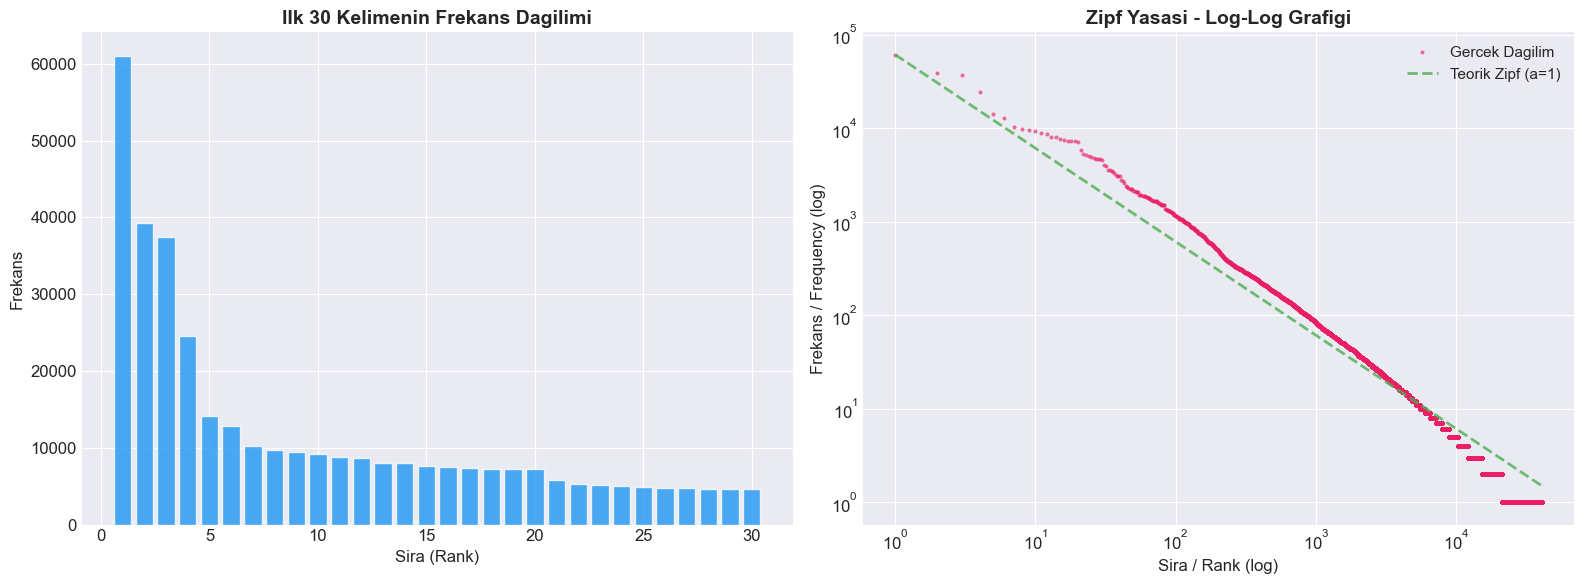


Toplam benzersiz kelime sayisi: 40,694
Toplam kelime sayisi: 916,735


In [4]:
# --- Zipf Yasasi: Ham veri uzerinde kelime frekanslari ---
all_words_raw = " ".join(df["ayet"].astype(str)).split()
word_freq = Counter(all_words_raw)

# En sik 20 kelime
print("Ham Veride En Sik 20 Kelime:")
print("-" * 40)
for i, (word, freq) in enumerate(word_freq.most_common(20), 1):
    print(f"  {i:2d}. {word:<20s} -> {freq:,}")

# Rank ve Frequency hesapla
freq_sorted = sorted(word_freq.values(), reverse=True)
ranks = range(1, len(freq_sorted) + 1)

# Log-Log Grafigi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Ham frekans dagilimi
axes[0].bar(range(1, 31), freq_sorted[:30], color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Sira (Rank)', fontsize=12)
axes[0].set_ylabel('Frekans', fontsize=12)
axes[0].set_title('Ilk 30 Kelimenin Frekans Dagilimi', fontsize=14, fontweight='bold')

# Sag: Log-Log grafigi (Zipf Yasasi)
axes[1].loglog(ranks, freq_sorted, '.', color='#E91E63', alpha=0.5, markersize=4, label='Gercek Dagilim')

# Teorik Zipf cizgisi
C = freq_sorted[0]
zipf_theoretical = [C / r for r in ranks]
axes[1].loglog(ranks, zipf_theoretical, '--', color='#4CAF50', linewidth=2, alpha=0.8, label='Teorik Zipf (a=1)')

axes[1].set_xlabel('Sira / Rank (log)', fontsize=12)
axes[1].set_ylabel('Frekans / Frequency (log)', fontsize=12)
axes[1].set_title("Zipf Yasasi - Log-Log Grafigi", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('zipf_yasasi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nToplam benzersiz kelime sayisi: {len(word_freq):,}")
print(f"Toplam kelime sayisi: {len(all_words_raw):,}")

## 4. Metin On Isleme (Pre-processing)

Asagidaki adimlar sirasiyla uygulanacaktir. Her adimdan sonra verinin **onceki** ve **sonraki** hali karsilastirmali olarak gosterilecektir.

**Islem Sirasi:**
1. Genel Icerik Temizligi (HTML, ozel karakterler, sayilar)
2. Kucuk Harfe Donusturme (Lowercasing)
3. Tokenization (Kelimelere Ayirma)
4. Stop Word Removal (Durak Kelime Cikarma)
5. Lemmatization (Kok Bulma - Sozluk Tabanli)
6. Stemming (Govde Bulma - Kural Tabanli)

### 4a. Genel Icerik Temizligi

Bu adimda asagidaki islemler yapilir:
- **HTML etiketleri** kaldirilir
- **Ozel karakterler** ve semboller temizlenir
- **Sayilar** kaldirilir
- **Fazla bosluklar** tek bosluga indirilir

> **Kullanilan Kutuphane:** `re` (Regular Expressions - Duzenli Ifadeler)

In [5]:
# re kutuphanesi kullanilarak metin temizligi
def temizle(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)                # HTML etiketlerini kaldir
    text = re.sub(r'\{[^}]*\}', '', text)              # Suslu parantez notlarini kaldir
    text = re.sub(r'[0-9]+', '', text)                 # Sayilari kaldir
    text = re.sub(r"[^a-zA-Z\s.,;:!?'-]", '', text)   # Sadece harf ve temel noktalama birak
    text = re.sub(r'\s+', ' ', text).strip()           # Fazla bosluklari temizle
    return text

# ONCEKI HAL
print("ONCEKI HAL (ham ayet):")
print(df[["kaynak", "ayet"]].head(8).to_string(index=False))

# Temizleme uygula
df["ayet_temiz"] = df["ayet"].apply(temizle)

# SONRAKI HAL
print("\nSONRAKI HAL (temizlenmis):")
print(df[["kaynak", "ayet_temiz"]].head(8).to_string(index=False))

ONCEKI HAL (ham ayet):
kaynak                                                                                           ayet
 Kuran                                    In the Name of Allah—the Most Compassionate, Most Merciful.
 Kuran                                                    All praise is for Allah—Lord of all worlds,
 Kuran                                                         the Most Compassionate, Most Merciful,
 Kuran                                                                 Master of the Day of Judgment.
 Kuran                                        You ˹alone˺ we worship and You ˹alone˺ we ask for help.
 Kuran                                                              Guide us along the Straight Path,
 Kuran the Path of those You have blessed—not those You are displeased with, or those who are astray.
 Kuran                                                                                  Alif-Lãm-Mĩm.

SONRAKI HAL (temizlenmis):
kaynak                         

### 4b. Kucuk Harfe Donusturme (Lowercasing)

Buyuk/kucuk harf farkliliklarinin ortadan kaldirilmasi, 'God' ve 'god' gibi ayni kelimelerin tek bir form olarak sayilmasini saglar. Bu, kelime frekans analizlerinde tutarlilik kazandirir.

In [6]:
# ONCEKI HAL
print("ONCEKI HAL:")
print(df[["kaynak", "ayet_temiz"]].head(5).to_string(index=False))

# Kucuk harfe donustur
df["ayet_lower"] = df["ayet_temiz"].str.lower()

# SONRAKI HAL
print("\nSONRAKI HAL (lowercase):")
print(df[["kaynak", "ayet_lower"]].head(5).to_string(index=False))

ONCEKI HAL:
kaynak                                                 ayet_temiz
 Kuran In the Name of Allahthe Most Compassionate, Most Merciful.
 Kuran                 All praise is for AllahLord of all worlds,
 Kuran                     the Most Compassionate, Most Merciful,
 Kuran                             Master of the Day of Judgment.
 Kuran        You alone we worship and You alone we ask for help.

SONRAKI HAL (lowercase):
kaynak                                                 ayet_lower
 Kuran in the name of allahthe most compassionate, most merciful.
 Kuran                 all praise is for allahlord of all worlds,
 Kuran                     the most compassionate, most merciful,
 Kuran                             master of the day of judgment.
 Kuran        you alone we worship and you alone we ask for help.


### 4c. Tokenization (Kelimelere Ayirma)

Tokenization, metni anlamli birimlere (kelimelere) ayirma islemidir. Bu adimda:
- Metin kelimelere ayrilir (`word_tokenize`)
- Noktalama isaretleri kaldirilir
- Cumle yapisi korunarak her ayet ayri ayri tokenize edilir

> **Kullanilan Kutuphane:** `nltk.tokenize.word_tokenize`

In [7]:
# NLTK word_tokenize kullanilarak tokenization
def tokenize_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    return tokens

# ONCEKI HAL
print("ONCEKI HAL (metin):")
print(df[["kaynak", "ayet_lower"]].head(5).to_string(index=False))

# Tokenization uygula
df["ayet_tokens"] = df["ayet_lower"].apply(tokenize_text)

# SONRAKI HAL
print("\nSONRAKI HAL (tokenized):")
for i, row in df.head(5).iterrows():
    print(f"  [{row['kaynak']}] {row['ayet_tokens'][:10]}...")

print(f"\nOrtalama token sayisi: {df['ayet_tokens'].apply(len).mean():.1f}")

ONCEKI HAL (metin):
kaynak                                                 ayet_lower
 Kuran in the name of allahthe most compassionate, most merciful.
 Kuran                 all praise is for allahlord of all worlds,
 Kuran                     the most compassionate, most merciful,
 Kuran                             master of the day of judgment.
 Kuran        you alone we worship and you alone we ask for help.

SONRAKI HAL (tokenized):
  [Kuran] ['in', 'the', 'name', 'of', 'allahthe', 'most', 'compassionate', 'most', 'merciful']...
  [Kuran] ['all', 'praise', 'is', 'for', 'allahlord', 'of', 'all', 'worlds']...
  [Kuran] ['the', 'most', 'compassionate', 'most', 'merciful']...
  [Kuran] ['master', 'of', 'the', 'day', 'of', 'judgment']...
  [Kuran] ['you', 'alone', 'we', 'worship', 'and', 'you', 'alone', 'we', 'ask', 'for']...

Ortalama token sayisi: 24.4


### 4d. Stop Word Removal (Durak Kelime Cikarma)

Stop word'ler (durak kelimeler), dilde cok sik kullanilan ancak anlam tasimayan kelimelerdir: *the, is, at, which, on, a, an* vb.

Bu kelimelerin cikarilmasi, anlamli kelimelerin one cikmasini saglar.

> **Kullanilan Kutuphane:** `nltk.corpus.stopwords` (Ingilizce stop word listesi)

In [8]:
# NLTK Ingilizce stop word listesi
stop_words = set(stopwords.words('english'))
print(f"Stop word sayisi: {len(stop_words)}")
print(f"   Ornekler: {list(stop_words)[:15]}")

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

# ONCEKI HAL
print("\nONCEKI HAL (tokenized):")
for i, row in df.head(3).iterrows():
    print(f"  [{row['kaynak']}] Token sayisi: {len(row['ayet_tokens'])} -> {row['ayet_tokens'][:8]}")

# Stop word cikarma
df["ayet_no_stop"] = df["ayet_tokens"].apply(remove_stopwords)

# SONRAKI HAL
print("\nSONRAKI HAL (stop words removed):")
for i, row in df.head(3).iterrows():
    print(f"  [{row['kaynak']}] Token sayisi: {len(row['ayet_no_stop'])} -> {row['ayet_no_stop'][:8]}")

# Istatistik
before_avg = df["ayet_tokens"].apply(len).mean()
after_avg = df["ayet_no_stop"].apply(len).mean()
print(f"\nOrtalama token: {before_avg:.1f} -> {after_avg:.1f} (Azalma: %{((before_avg-after_avg)/before_avg)*100:.1f})")

Stop word sayisi: 198
   Ornekler: ['needn', 'i', 'about', 'have', 'between', 'been', 'being', 'doesn', 'until', 't', 'am', 'can', 'its', 'does', 'off']

ONCEKI HAL (tokenized):
  [Kuran] Token sayisi: 9 -> ['in', 'the', 'name', 'of', 'allahthe', 'most', 'compassionate', 'most']
  [Kuran] Token sayisi: 8 -> ['all', 'praise', 'is', 'for', 'allahlord', 'of', 'all', 'worlds']
  [Kuran] Token sayisi: 5 -> ['the', 'most', 'compassionate', 'most', 'merciful']

SONRAKI HAL (stop words removed):
  [Kuran] Token sayisi: 4 -> ['name', 'allahthe', 'compassionate', 'merciful']
  [Kuran] Token sayisi: 3 -> ['praise', 'allahlord', 'worlds']
  [Kuran] Token sayisi: 2 -> ['compassionate', 'merciful']

Ortalama token: 24.4 -> 10.6 (Azalma: %56.5)


### 4e. Lemmatization (Sozluk Tabanli Koke Indirgeme)

Lemmatization, kelimeleri **sozluk formlarina** (lemma) indirger. Ornegin:
- *running* -> *run*
- *better* -> *good*
- *children* -> *child*

Stemming'den farki, sonucun her zaman gecerli bir kelime olmasidir.

> **Kullanilan Kutuphane:** `nltk.stem.WordNetLemmatizer`

In [9]:
# NLTK WordNetLemmatizer kullanilarak lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t, pos='v') for t in tokens]

# ONCEKI HAL
print("ONCEKI HAL (stop words removed):")
for i, row in df.head(3).iterrows():
    print(f"  [{row['kaynak']}] {row['ayet_no_stop'][:8]}")

# Lemmatization uygula
df["ayet_lemmatized"] = df["ayet_no_stop"].apply(lemmatize_tokens)

# SONRAKI HAL
print("\nSONRAKI HAL (lemmatized):")
for i, row in df.head(3).iterrows():
    print(f"  [{row['kaynak']}] {row['ayet_lemmatized'][:8]}")

# Lemmatized metni string olarak birlestir
df["ayet_lemma_str"] = df["ayet_lemmatized"].apply(lambda x: " ".join(x))
print("\nLemmatized metin ornegi:")
print(df[["kaynak", "ayet_lemma_str"]].head(3).to_string(index=False))

ONCEKI HAL (stop words removed):
  [Kuran] ['name', 'allahthe', 'compassionate', 'merciful']
  [Kuran] ['praise', 'allahlord', 'worlds']
  [Kuran] ['compassionate', 'merciful']

SONRAKI HAL (lemmatized):
  [Kuran] ['name', 'allahthe', 'compassionate', 'merciful']
  [Kuran] ['praise', 'allahlord', 'worlds']
  [Kuran] ['compassionate', 'merciful']

Lemmatized metin ornegi:
kaynak                       ayet_lemma_str
 Kuran name allahthe compassionate merciful
 Kuran              praise allahlord worlds
 Kuran               compassionate merciful


### 4f. Stemming (Kural Tabanli Govdeleme)

Stemming, kelimeleri ekleri keserek **govdelerine** indirger. Lemmatization'dan daha agresiftir ve sonuc her zaman gecerli bir kelime olmayabilir. Ornegin:
- *running* -> *run*
- *generously* -> *generous* (veya *gener*)
- *studies* -> *studi*

> **Kullanilan Kutuphane:** `nltk.stem.SnowballStemmer` (Ingilizce)

In [10]:
# NLTK SnowballStemmer kullanilarak stemming (Ingilizce)
stemmer = SnowballStemmer("english")

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

# ONCEKI HAL
print("ONCEKI HAL (stop words removed):")
for i, row in df.head(3).iterrows():
    print(f"  [{row['kaynak']}] {row['ayet_no_stop'][:8]}")

# Stemming uygula (stop words cikarilmis tokenlerden)
df["ayet_stemmed"] = df["ayet_no_stop"].apply(stem_tokens)

# SONRAKI HAL
print("\nSONRAKI HAL (stemmed):")
for i, row in df.head(3).iterrows():
    print(f"  [{row['kaynak']}] {row['ayet_stemmed'][:8]}")

# Stemmed metni string olarak birlestir
df["ayet_stem_str"] = df["ayet_stemmed"].apply(lambda x: " ".join(x))
print("\nStemmed metin ornegi:")
print(df[["kaynak", "ayet_stem_str"]].head(3).to_string(index=False))

ONCEKI HAL (stop words removed):
  [Kuran] ['name', 'allahthe', 'compassionate', 'merciful']
  [Kuran] ['praise', 'allahlord', 'worlds']
  [Kuran] ['compassionate', 'merciful']

SONRAKI HAL (stemmed):
  [Kuran] ['name', 'allahth', 'compassion', 'merci']
  [Kuran] ['prais', 'allahlord', 'world']
  [Kuran] ['compassion', 'merci']

Stemmed metin ornegi:
kaynak                 ayet_stem_str
 Kuran name allahth compassion merci
 Kuran         prais allahlord world
 Kuran              compassion merci


## 5. Veri Setlerini Disa Aktarma

Tum on isleme adimlari tamamlandiktan sonra, asagidaki 3 farkli CSV dosyasi GitHub'a yuklenecek sekilde disa aktarilir:

| Dosya | Icerik |
|-------|--------|
| `ham_veri.csv` | Orijinal, temizlenmemis metin verisi |
| `stemmed_veri.csv` | Stemming uygulanmis metin verisi |
| `lemmatized_veri.csv` | Lemmatization uygulanmis metin verisi |

Her dosya, model egitimine uygun temiz bir CSV yapisindadir.

In [11]:
# Disa aktarilacak temel sutunlar
BASE_COLS = ["sure_no", "sure_ismi", "bolum", "ayet_no", "kaynak"]

# --- 1. Ham Veri ---
ham = df[BASE_COLS + ["ayet"]].copy()
ham.to_csv("ham_veri.csv", index=False, encoding="utf-8-sig")
print(f"ham_veri.csv kaydedildi ({len(ham):,} satir)")

# --- 2. Stemmed Veri ---
stemmed = df[BASE_COLS].copy()
stemmed["ayet"] = df["ayet_stem_str"]
stemmed.to_csv("stemmed_veri.csv", index=False, encoding="utf-8-sig")
print(f"stemmed_veri.csv kaydedildi ({len(stemmed):,} satir)")

# --- 3. Lemmatized Veri ---
lemmatized = df[BASE_COLS].copy()
lemmatized["ayet"] = df["ayet_lemma_str"]
lemmatized.to_csv("lemmatized_veri.csv", index=False, encoding="utf-8-sig")
print(f"lemmatized_veri.csv kaydedildi ({len(lemmatized):,} satir)")

print(f"\nTum dosyalar basariyla kaydedildi!")
print(f"   ham_veri.csv")
print(f"   stemmed_veri.csv")
print(f"   lemmatized_veri.csv")

ham_veri.csv kaydedildi (37,338 satir)
stemmed_veri.csv kaydedildi (37,338 satir)
lemmatized_veri.csv kaydedildi (37,338 satir)

Tum dosyalar basariyla kaydedildi!
   ham_veri.csv
   stemmed_veri.csv
   lemmatized_veri.csv


## Ozet

Bu notebook'ta gerceklestirilen islemler:

1. **Veri Yukleme:** Kuran, Incil ve Tevrat veri setleri yuklendi ve ortak formata donusturuldu.
2. **Zipf Yasasi:** Ham metin uzerinde kelime frekans analizi yapildi ve log-log grafigi cizildi.
3. **On Isleme Adimlari:**
   - Genel icerik temizligi (HTML, ozel karakter, sayi)
   - Kucuk harfe donusturme
   - Tokenization (kelimelere ayirma)
   - Stop word cikarma
   - Lemmatization (sozluk tabanli koke indirgeme)
   - Stemming (kural tabanli govdeleme)
4. **Disa Aktarma:** `ham_veri.csv`, `stemmed_veri.csv`, `lemmatized_veri.csv` dosyalari olusturuldu.

Veriler, ileride model egitimi icin kullanilmaya hazirdir.